### Read the SNOWPACK MLD4 WY2020-WY2025 Simulations

created by Cassie Lumbrazo\
last updated: April 2026\
run location: UAS linux\
python environment: **xarray**

In [8]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy
import os

In [9]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites/mld4'

## Put Some JIF Data info a simple dataframe to plot later

In [10]:
# create a new dataframe with field data above 
# site name = tkg4
# date = 2024-06-15, as in, June 15, 2024
# total core depth = 800 cm 
# snow-firm transition depth = 642.5 cm 

df_field_tkg4 = pd.DataFrame({
    'date': ['2024-06-15'],
    'site': ['tkg4'],
    'core_depth_cm': [800],
    'snow_firm_transition_depth_cm': [642.5]
})

# df_field_tkg4 date to datetime
df_field_tkg4['date'] = pd.to_datetime(df_field_tkg4['date'])
df_field_tkg4


,date,site,core_depth_cm,snow_firm_transition_depth_cm
0,2024-06-15,tkg4,800,642.5


In [30]:
# create a new dataframe with the field data from MLD4 site 
# site name = mld4
# date = 2024-06-11, as in June 11, 2024
# total core depth = 678.5 cm

# date = 2024-06-18, as in June 18, 2024
# total core depth = 657 cm 

df_field_mld4 = pd.DataFrame({
    'date': ['2024-06-11', '2024-06-18'],
    'site': ['mld4', 'mld4'],
    'core_depth_cm': [678.5, 657]
})

# df_field_mld4 date to datetime
df_field_mld4['date'] = pd.to_datetime(df_field_mld4['date'])
df_field_mld4

,date,site,core_depth_cm
0,2024-06-11,mld4,678.5
1,2024-06-18,mld4,657.0


# Open Data and Model Simulations

## Function for Reading SMET Files 

In [12]:
def read_smet(filepath):
    header = {}
    fields = None
    data_start = None

    # Read file and parse header
    with open(filepath, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect fields line
        if line.startswith("fields"):
            fields = line.split("=")[1].strip().split()

        # Detect start of data
        if line == "[DATA]":
            data_start = i + 1
            break

        # Parse header key-value pairs
        if "=" in line and not line.startswith("["):
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()

    if fields is None:
        raise ValueError("No 'fields' line found in SMET header.")
    if data_start is None:
        raise ValueError("No [DATA] section found.")

    # Read data into DataFrame
    df = pd.read_csv(
        filepath,
        skiprows=data_start,
        delim_whitespace=True,
        names=fields,
        parse_dates=["timestamp"]
    )

    # Set timestamp as index
    df = df.set_index("timestamp")

    # Convert to xarray
    ds = xr.Dataset.from_dataframe(df)

    return ds, header

## Open SNOWPACK SMet Output for WY2020-WY2025

In [13]:
ds_snowpack, header = read_smet("/home/cassie/python/models/run_snowpack/sites/mld4/output/hrrrak_mld4_WY2020-WY2025_heatflux_soiltemp_zero.smet")

print(ds_snowpack)
print(header)

/tmp/ipykernel_3058797/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


<xarray.Dataset> Size: 26MB
Dimensions:               (timestamp: 51673)
Coordinates:
  * timestamp             (timestamp) datetime64[ns] 413kB 2019-10-10T05:00:0...
Data variables: (12/63)
    Qs                    (timestamp) float64 413kB -898.6 -989.3 ... 133.1
    Ql                    (timestamp) float64 413kB -1.068e+03 ... -67.99
    Qg                    (timestamp) float64 413kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    TSG                   (timestamp) float64 413kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Qg0                   (timestamp) float64 413kB -999.0 -999.0 ... 0.0 0.0
    Qr                    (timestamp) float64 413kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ...                    ...
    zSs                   (timestamp) float64 413kB 0.0 0.0 ... 1.257e+03
    Ss                    (timestamp) float64 413kB 6.0 6.0 6.0 ... 0.353 0.353
    zS4                   (timestamp) float64 413kB 0.0 0.0 ... 1.257e+03
    S4                    (timestamp) float64 413kB 6.0 6.0 6.0 ... 2.353 2.353
  

Text(0, 0.5, 'snow depth (cm)')

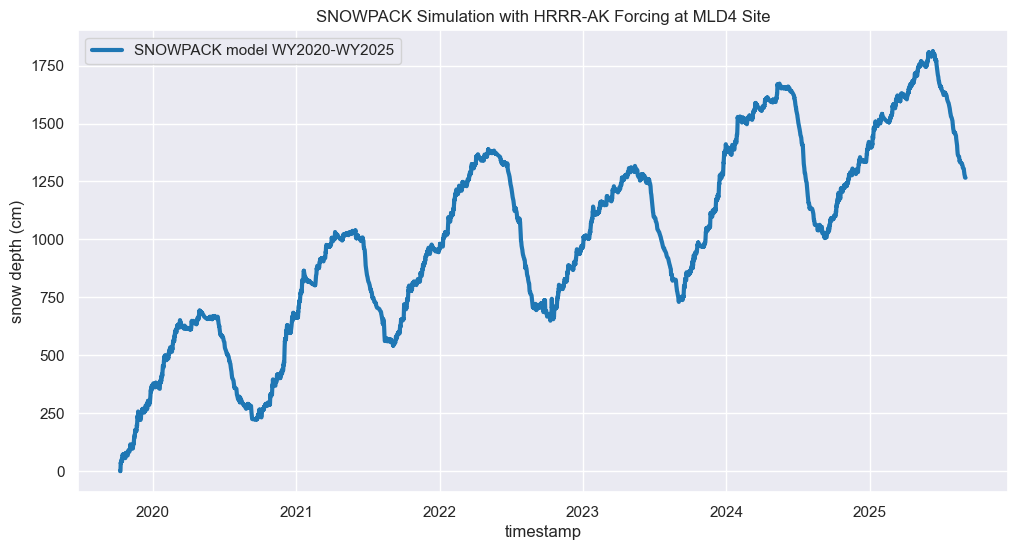

In [63]:
ds_snowpack.HS_mod.plot(label = 'SNOWPACK model WY2020-WY2025', linewidth = 3, color='tab:blue')

plt.title('SNOWPACK Simulation with HRRR-AK Forcing at MLD4 Site')
plt.legend()

plt.ylabel('snow depth (cm)')

Text(0.5, 1.0, 'SNOWPACK Simulation with HRRR-AK Forcing at MLD4 Site')

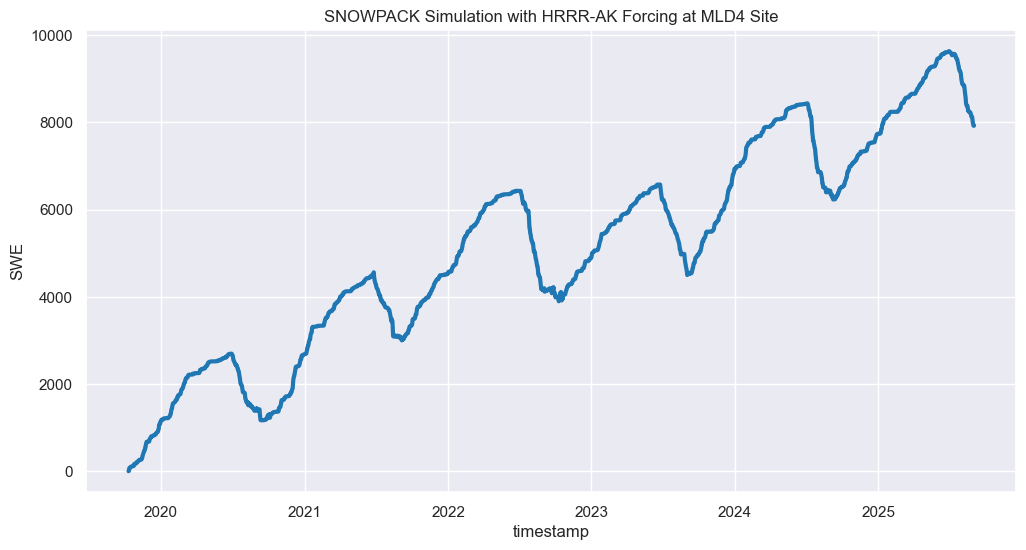

In [42]:
# plot SWE 
ds_snowpack.SWE.plot(label = 'SNOWPACK model WY2024', linewidth = 3, color='tab:blue')

plt.title('SNOWPACK Simulation with HRRR-AK Forcing at MLD4 Site')


In [32]:
df_field_mld4

,date,site,core_depth_cm
0,2024-06-11,mld4,678.5
1,2024-06-18,mld4,657.0


In [67]:
df_field_mld4['core_depth_cm_fixed'] = df_field_mld4['core_depth_cm'] + 730.36 # min value found in code below, this is temporary

Text(0, 0.5, 'snow depth (cm)')

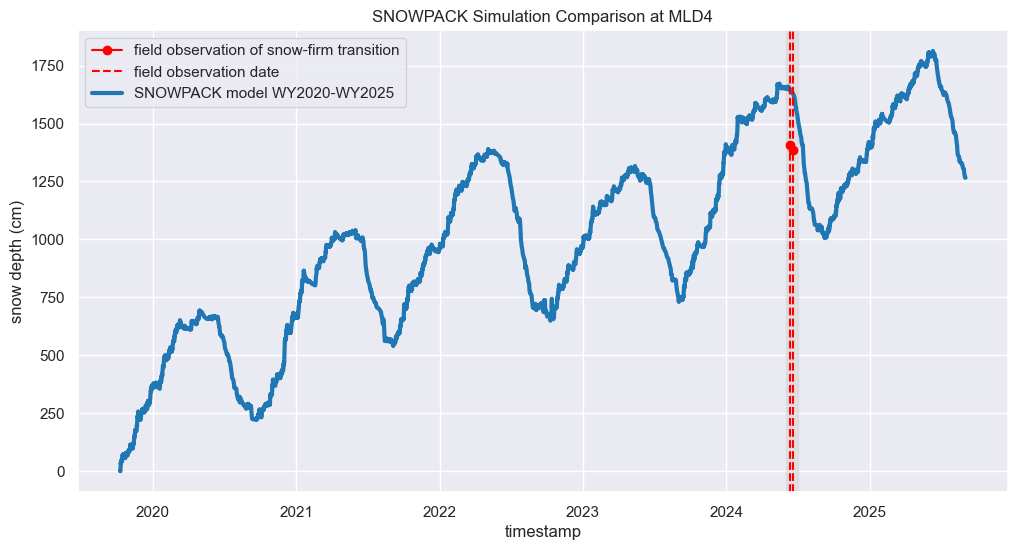

In [68]:
# and plot ds_snowpack and ds_snowpack_2 together for comparison
ds_snowpack.HS_mod.plot(label = 'SNOWPACK model WY2020-WY2025', linewidth = 3, color='tab:blue')

# highlight the space between June 1 and July 1 in light grey fill
plt.axvspan('2024-06-01', '2024-07-01', color='lightgrey', alpha=0.5)

# add a vertical line at June 15, 2024 to indicate the date of the field observation
plt.axvline(df_field_mld4['date'].iloc[0], color='red', linestyle='--', label='field observation date')
plt.axvline(df_field_mld4['date'].iloc[1], color='red', linestyle='--', label=None)

# plot df snow-firm 
# plt.plot(df_field_mld4['date'], df_field_mld4['core_depth_cm'], marker='o', color='red', label='field observation of snow-firm transition')
plt.plot(df_field_mld4['date'], df_field_mld4['core_depth_cm_fixed'], marker='o', color='red', label='field observation of snow-firm transition')

plt.title('SNOWPACK Simulation Comparison at MLD4')

# show the legend in the reverse order 
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1])
plt.ylabel('snow depth (cm)')


In [44]:
# what is the modeled snow depth on June 15, 2024 in each simulation?
snow_depth_on_ob1 = ds_snowpack.HS_mod.sel(timestamp=df_field_mld4['date'].iloc[0], method='nearest').values
snow_depth_on_ob2 = ds_snowpack.HS_mod.sel(timestamp=df_field_mld4['date'].iloc[1], method='nearest').values

# print the value for the snow depth on observation date 
print(f"Modeled snow depth on obs1: {snow_depth_on_ob1:.2f} cm")
print(f"Modeled snow depth on obs2: {snow_depth_on_ob2:.2f} cm")

# print the value for the firn-snow transiation depth on June 15, 2024 in df_field_mld4
print(f"Field observation of snow-firm transition depth on obs1: {df_field_mld4['core_depth_cm'].iloc[0]:.2f} cm")
print(f"Field observation of snow-firm transition depth on obs2: {df_field_mld4['core_depth_cm'].iloc[1]:.2f} cm")

Modeled snow depth on obs1: 1641.72 cm
Modeled snow depth on obs2: 1630.70 cm
Field observation of snow-firm transition depth on obs1: 678.50 cm
Field observation of snow-firm transition depth on obs2: 657.00 cm


# Remove the lead up to WY2024

Text(0.5, 1.0, 'SNOWPACK Simulation with HRRR-AK Forcing at MLD4 Site')

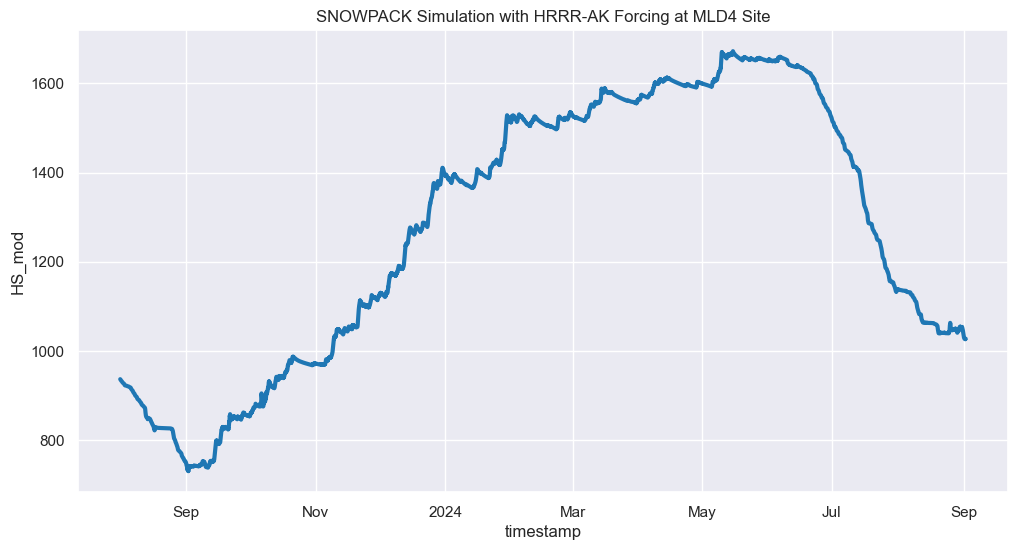

In [96]:
# we want to focus on WY2024
# so let's remove all the data before 

hs_model_ds = ds_snowpack.HS_mod.copy(deep=True)
# now, only keep the dates between 2023-09-01 and 2024-09-01
hs_model_ds = hs_model_ds.sel(timestamp=slice('2023-08-01', '2024-09-01'))
hs_model_ds.plot(label = 'SNOWPACK model WY2024', linewidth = 3, color='tab:blue')

plt.title('SNOWPACK Simulation with HRRR-AK Forcing at MLD4 Site')

In [97]:
# print the minimum value in the timeseries 
print(f"Minimum snow depth in WY2024: {hs_model_ds.min().values:.2f} cm")


Minimum snow depth in WY2024: 730.36 cm


Text(0.5, 1.0, 'SNOWPACK Simulation Comparison at MLD4 (min subtracted)')

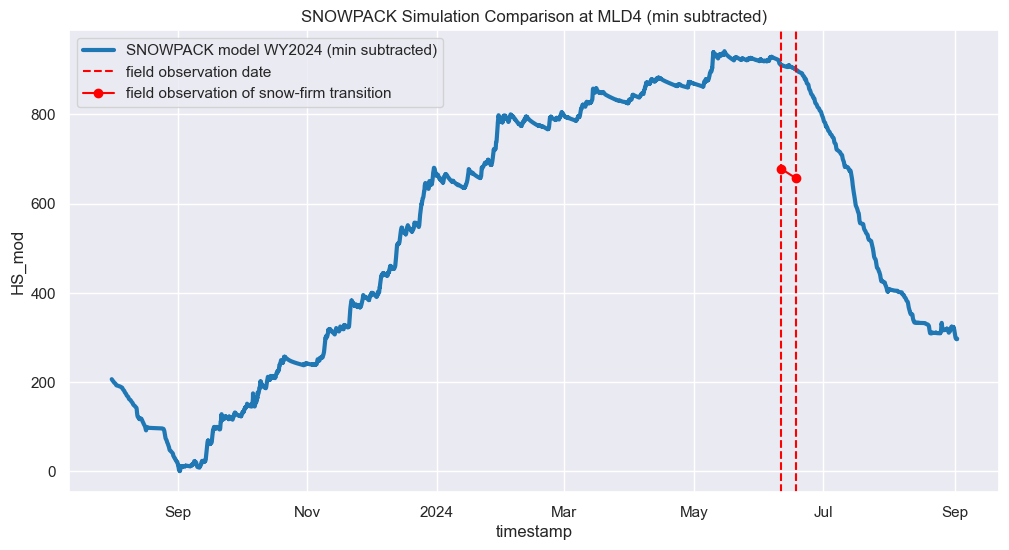

In [98]:
# now, subtract the entire dataset from the minimum value in the dataset 
hs_model_ds = hs_model_ds - hs_model_ds.min()
hs_model_ds.plot(label = 'SNOWPACK model WY2024 (min subtracted)', linewidth = 3, color='tab:blue')

# add a vertical line at June 15, 2024 to indicate the date of the field observation
plt.axvline(df_field_mld4['date'].iloc[0], color='red', linestyle='--', label='field observation date')
plt.axvline(df_field_mld4['date'].iloc[1], color='red', linestyle='--', label=None)

# plot df snow-firm 
plt.plot(df_field_mld4['date'], df_field_mld4['core_depth_cm'], marker='o', color='red', label='field observation of snow-firm transition')
plt.legend()
plt.title('SNOWPACK Simulation Comparison at MLD4 (min subtracted)')

### Now, load the WY2024 simulation files 

In [107]:
ds_snowpack_WY2024, header = read_smet("/home/cassie/python/models/run_snowpack/sites/mld4/output/hrrrak_mld4_WY2024-WY2025_heatflux_soiltemp_zero.smet")

/tmp/ipykernel_3058797/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


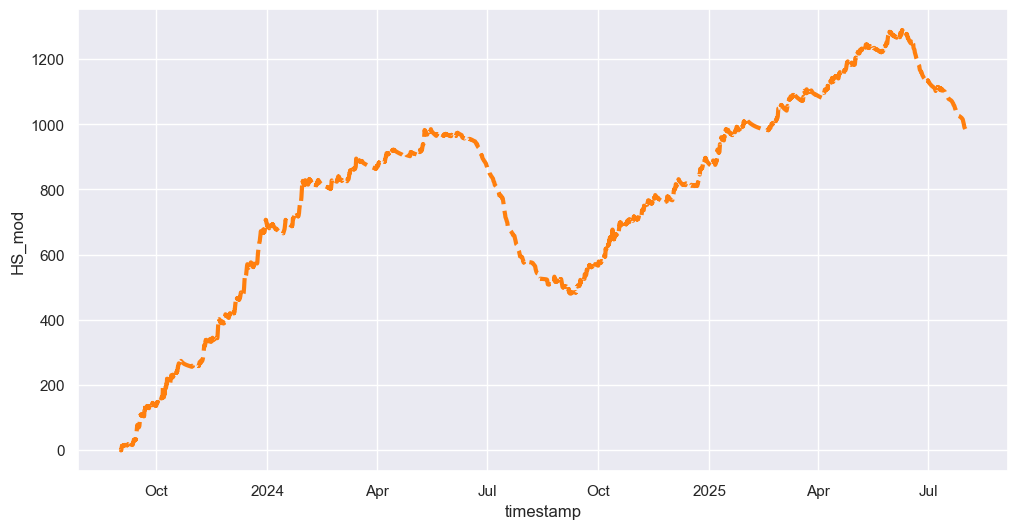

In [108]:
ds_snowpack_WY2024.HS_mod.plot(label = 'SNOWPACK model WY2024-WY2025', linewidth = 3, color='tab:orange', linestyle='--')

Text(0, 0.5, 'snow depth (cm)')

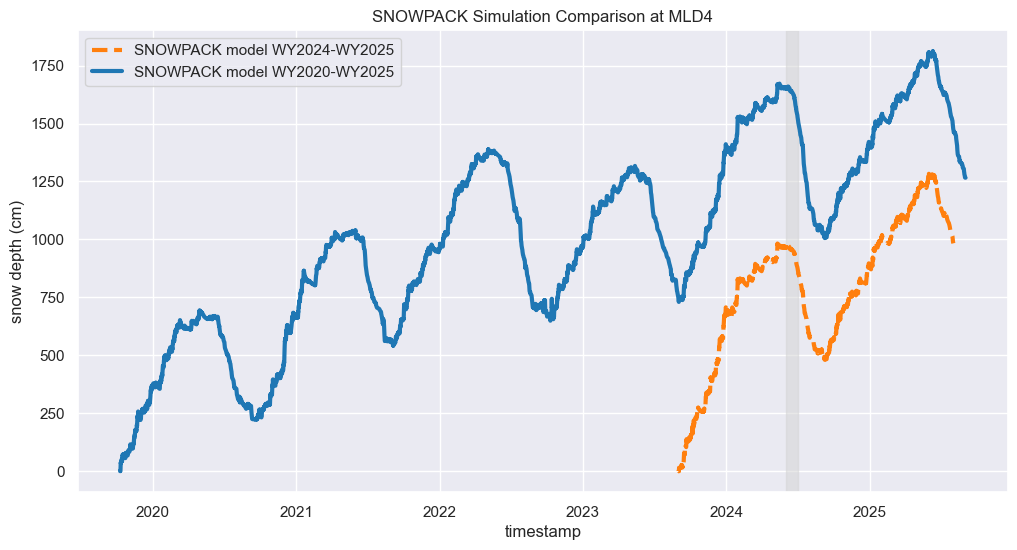

In [123]:
# and plot ds_snowpack and ds_snowpack_2 together for comparison
ds_snowpack.HS_mod.plot(label = 'SNOWPACK model WY2020-WY2025', linewidth = 3, color='tab:blue')
ds_snowpack_WY2024.HS_mod.plot(label = 'SNOWPACK model WY2024-WY2025', linewidth = 3, color='tab:orange', linestyle='--')

# highlight the space between June 1 and July 1 in light grey fill
plt.axvspan('2024-06-01', '2024-07-01', color='lightgrey', alpha=0.5)

# add a vertical line at June 15, 2024 to indicate the date of the field observation
# plt.axvline(df_field_mld4['date'].iloc[0], color='red', linestyle='--', label='field observation date')
# plt.axvline(df_field_mld4['date'].iloc[1], color='red', linestyle='--', label=None)

# plot df snow-firm 
# plt.plot(df_field_mld4['date'], df_field_mld4['core_depth_cm'], marker='o', color='red', label='field observation of snow-firm transition')
# plt.plot(df_field_mld4['date'], df_field_mld4['core_depth_cm_fixed'], marker='o', color='red', label='field observation of snow-firm transition')

plt.title('SNOWPACK Simulation Comparison at MLD4')

# show the legend in the reverse order 
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1])
plt.ylabel('snow depth (cm)')


In [110]:
# cut ds_snowpack_WY2024 to 2024-09-01
ds_snowpack_WY2024_cut = ds_snowpack_WY2024.sel(timestamp=slice('2023-08-01', '2024-09-01'))

Text(0.5, 1.0, 'SNOWPACK Simulation Comparison at MLD4 (min subtracted)')

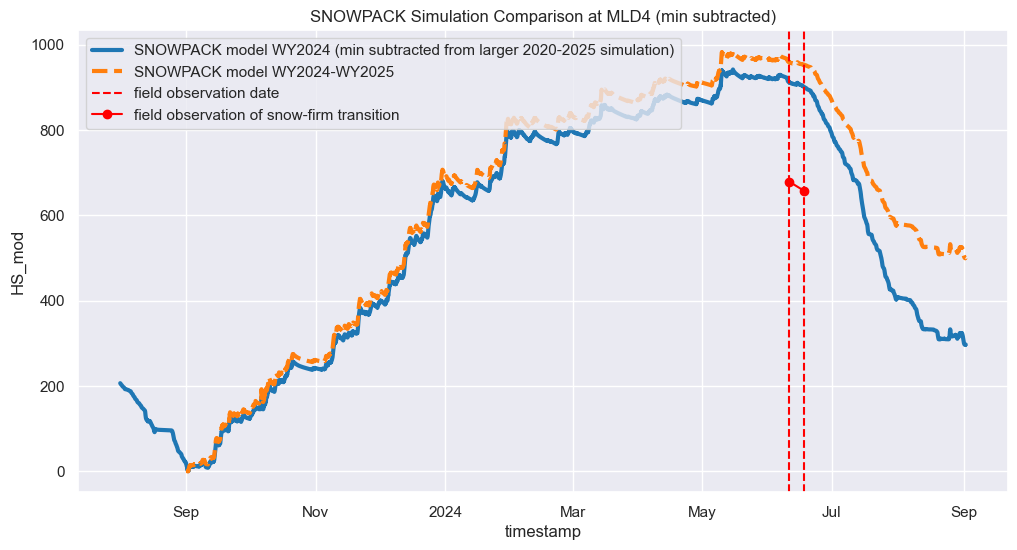

In [111]:
# now, subtract the entire dataset from the minimum value in the dataset 
hs_model_ds = hs_model_ds - hs_model_ds.min()
hs_model_ds.plot(label = 'SNOWPACK model WY2024 (min subtracted from larger 2020-2025 simulation)', linewidth = 3, color='tab:blue')
# ds_snowpack_WY2024.HS_mod.plot(label = 'SNOWPACK model WY2024-WY2025', linewidth = 3, color='tab:orange', linestyle='--')
ds_snowpack_WY2024_cut.HS_mod.plot(label = 'SNOWPACK model WY2024-WY2025', linewidth = 3, color='tab:orange', linestyle='--')

# add a vertical line at June 15, 2024 to indicate the date of the field observation
plt.axvline(df_field_mld4['date'].iloc[0], color='red', linestyle='--', label='field observation date')
plt.axvline(df_field_mld4['date'].iloc[1], color='red', linestyle='--', label=None)

# plot df snow-firm 
plt.plot(df_field_mld4['date'], df_field_mld4['core_depth_cm'], marker='o', color='red', label='field observation of snow-firm transition')
plt.legend(loc='upper left')
plt.title('SNOWPACK Simulation Comparison at MLD4 (min subtracted)')

In [122]:
# what is the modeled snow depth on June 15, 2024 in each simulation?
snow_depth_on_ob1 = ds_snowpack.HS_mod.sel(timestamp=df_field_mld4['date'].iloc[0], method='nearest').values
snow_depth_on_obs1_WY2024 = ds_snowpack_WY2024_cut.HS_mod.sel(timestamp=df_field_mld4['date'].iloc[0], method='nearest').values

# print the value for the snow depth on observation date 
# subtract 730.36 from the modeled snow depth to account for the minimum value in the dataset, this is temporary
print(f"Field observation of snow-firm transition depth on obs1: {df_field_mld4['core_depth_cm'].iloc[0]:.2f} cm")
print(f"Modeled snow depth on obs1 (WY2020-WY2025 simulation): {snow_depth_on_ob1:.2f} cm")
print(f"Modeled snow depth on obs1 (WY2024-WY2025 simulation): {snow_depth_on_obs1_WY2024:.2f} cm")

snow_depth_on_ob2 = ds_snowpack.HS_mod.sel(timestamp=df_field_mld4['date'].iloc[1], method='nearest').values
snow_depth_on_obs2_WY2024 = ds_snowpack_WY2024_cut.HS_mod.sel(timestamp=df_field_mld4['date'].iloc[1], method='nearest').values
print('')


print(f"Field observation of snow-firm transition depth on obs2: {df_field_mld4['core_depth_cm'].iloc[1]:.2f} cm")
print(f"Modeled snow depth on obs2 (WY2020-WY2025 simulation): {snow_depth_on_ob2:.2f} cm")
print(f"Modeled snow depth on obs2 (WY2024-WY2025 simulation): {snow_depth_on_obs2_WY2024:.2f} cm")

Field observation of snow-firm transition depth on obs1: 678.50 cm
Modeled snow depth on obs1 (WY2020-WY2025 simulation): 1641.72 cm
Modeled snow depth on obs1 (WY2024-WY2025 simulation): 958.48 cm

Field observation of snow-firm transition depth on obs2: 657.00 cm
Modeled snow depth on obs2 (WY2020-WY2025 simulation): 1630.70 cm
Modeled snow depth on obs2 (WY2024-WY2025 simulation): 952.72 cm


730.36 cm

Modeled snow depth on obs1: 1641.72 cm -
Modeled snow depth on obs2: 1630.70 cm
Field observation of snow-firm transition depth on obs1: 678.50 cm
Field observation of snow-firm transition depth on obs2: 657.00 cm